# 07 — Claim Occurrence Tuning & Calibration

## Projet : AI Business Advisor V2

L'étape précédente a montré que XGBoost possède la meilleure capacité
de discrimination pour la prédiction de l'occurrence d'un sinistre.

Résultats principaux :

DummyClassifier :
PR-AUC ≈ 0.0503

Logistic Regression :
PR-AUC ≈ 0.0926
Brier ≈ 0.0470

Random Forest :
PR-AUC ≈ 0.1050

XGBoost :
PR-AUC ≈ 0.1434
ROC-AUC ≈ 0.7065
Brier ≈ 0.2041

XGBoost améliore nettement la discrimination mais ses probabilités
brutes sont mal calibrées.

Cette étape vise donc à :

1. ajuster les hyperparamètres de XGBoost ;
2. ajuster la régularisation de Logistic Regression ;
3. comparer les probabilités avant et après calibration ;
4. étudier le seuil de classification ;
5. verrouiller une configuration candidate avant le test final.

Le jeu de test final n'est pas utilisé dans ce notebook.

In [2]:
import pandas as pd
import numpy as np

import json
import time

import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression

from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    log_loss,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    confusion_matrix
)

from xgboost import XGBClassifier


RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [3]:
cwd = Path.cwd()

possible_processed_paths = [
    cwd / "data" / "processed",
    cwd / "data-science" / "data" / "processed",
    cwd.parent / "data" / "processed"
]

PROCESSED_DIR = None

for path in possible_processed_paths:
    if path.exists():
        PROCESSED_DIR = path
        break

if PROCESSED_DIR is None:
    raise FileNotFoundError(
        "Impossible de localiser data/processed"
    )


DATA_DIR = PROCESSED_DIR.parent

METADATA_DIR = DATA_DIR / "metadata"

REPORT_DIR = (
    DATA_DIR.parent
    / "reports"
    / "models"
    / "claim_occurrence"
    / "tuning"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


occurrence = pd.read_csv(
    PROCESSED_DIR
    / "claim_occurrence_modeling_base.csv"
)

split_df = pd.read_csv(
    METADATA_DIR
    / "freMTPL2_split.csv"
)


with open(
    METADATA_DIR / "feature_manifest.json",
    "r",
    encoding="utf-8"
) as f:
    feature_manifest = json.load(f)


config = feature_manifest[
    "claim_occurrence"
]


print("Occurrence :", occurrence.shape)
print("Reports    :", REPORT_DIR.resolve())

Occurrence : (676789, 12)
Reports    : C:\Users\user\ai-business-advisor-v2\data-science\reports\models\claim_occurrence\tuning


In [4]:
occurrence = occurrence.merge(
    split_df,
    on="IDpol",
    how="left",
    validate="one_to_one"
)


occurrence_dev = (
    occurrence[
        occurrence["split"] == "development"
    ]
    .copy()
)

occurrence_test = (
    occurrence[
        occurrence["split"] == "test"
    ]
    .copy()
)


print(
    "DEV  :",
    occurrence_dev.shape
)

print(
    "TEST :",
    occurrence_test.shape
)

DEV  : (541431, 13)
TEST : (135358, 13)


In [5]:
assert set(
    occurrence_dev["IDpol"]
).isdisjoint(
    set(
        occurrence_test["IDpol"]
    )
)

print(
    "Séparation DEV / TEST : OK"
)

Séparation DEV / TEST : OK


In [6]:
numeric_features = (
    config["numeric_features"]
)

categorical_features = (
    config["categorical_features"]
)

features = (
    numeric_features
    +
    categorical_features
)

target = config["target"]


X_dev = (
    occurrence_dev[
        features
    ]
    .copy()
)

y_dev = (
    occurrence_dev[
        target
    ]
    .copy()
)

In [7]:
assert "ClaimNb" not in X_dev.columns
assert "has_claim" not in X_dev.columns
assert "IDpol" not in X_dev.columns

print(
    "Leakage checks : OK"
)

Leakage checks : OK


In [8]:
(
    X_model_dev,
    X_calibration,
    y_model_dev,
    y_calibration
) = train_test_split(
    X_dev,
    y_dev,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_dev
)

In [9]:
print(
    "MODEL DEV :",
    X_model_dev.shape
)

print(
    "CALIBRATION :",
    X_calibration.shape
)

print()

print(
    "Positive rate MODEL DEV :",
    y_model_dev.mean()
)

print(
    "Positive rate CALIBRATION :",
    y_calibration.mean()
)

MODEL DEV : (433144, 10)
CALIBRATION : (108287, 10)

Positive rate MODEL DEV : 0.05025118667233068
Positive rate CALIBRATION : 0.05024610525732544


In [10]:
numeric_linear_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [11]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [12]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_linear_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [13]:
numeric_tree_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

In [14]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_tree_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [15]:
tuning_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [16]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            linear_preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1500,
                random_state=RANDOM_STATE
            )
        )
    ]
)

In [17]:
logistic_params = {
    "model__C": [
        0.001,
        0.01,
        0.1,
        0.5,
        1.0,
        2.0,
        5.0,
        10.0,
        100.0
    ]
}

In [18]:
logistic_search = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=logistic_params,
    n_iter=len(
        logistic_params["model__C"]
    ),
    scoring="average_precision",
    cv=tuning_cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
    return_train_score=True
)

In [19]:
start = time.perf_counter()

logistic_search.fit(
    X_model_dev,
    y_model_dev
)

logistic_elapsed = (
    time.perf_counter()
    - start
)


print(
    "Best params :",
    logistic_search.best_params_
)

print(
    "Best CV PR-AUC :",
    logistic_search.best_score_
)

print(
    "Temps :",
    logistic_elapsed
)

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best params : {'model__C': 0.001}
Best CV PR-AUC : 0.09324613124601637
Temps : 102.14768029999686


In [20]:
logistic_search_results = pd.DataFrame(
    logistic_search.cv_results_
)

logistic_search_results.to_csv(
    REPORT_DIR
    / "logistic_tuning_results.csv",
    index=False
)

In [21]:
n_negative = (
    y_model_dev == 0
).sum()

n_positive = (
    y_model_dev == 1
).sum()

class_ratio = (
    n_negative
    /
    n_positive
)

print(
    "Class ratio :",
    class_ratio
)

Class ratio : 18.90002756592851


In [22]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

In [23]:
xgb_params = {

    "model__n_estimators": [
        200,
        300,
        500,
        700
    ],

    "model__learning_rate": [
        0.02,
        0.05,
        0.08,
        0.10
    ],

    "model__max_depth": [
        3,
        4,
        5,
        6,
        8
    ],

    "model__min_child_weight": [
        1,
        3,
        5,
        10
    ],

    "model__subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "model__colsample_bytree": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "model__reg_alpha": [
        0.0,
        0.01,
        0.1,
        1.0
    ],

    "model__reg_lambda": [
        1.0,
        2.0,
        5.0,
        10.0
    ],

    "model__scale_pos_weight": [
        1.0,
        3.0,
        5.0,
        10.0,
        float(class_ratio)
    ]
}


In [24]:
N_ITER_XGB = 20

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=N_ITER_XGB,
    scoring="average_precision",
    cv=tuning_cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

In [25]:
start = time.perf_counter()

xgb_search.fit(
    X_model_dev,
    y_model_dev
)

xgb_elapsed = (
    time.perf_counter()
    - start
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.02, model__max_depth=6, model__min_child_weight=10, model__n_estimators=300, model__reg_alpha=0.0, model__reg_lambda=2.0, model__scale_pos_weight=18.90002756592851, model__subsample=0.9; total time=  27.5s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.02, model__max_depth=6, model__min_child_weight=10, model__n_estimators=300, model__reg_alpha=0.0, model__reg_lambda=2.0, model__scale_pos_weight=18.90002756592851, model__subsample=0.9; total time=  16.6s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.02, model__max_depth=6, model__min_child_weight=10, model__n_estimators=300, model__reg_alpha=0.0, model__reg_lambda=2.0, model__scale_pos_weight=18.90002756592851, model__subsample=0.9; total time=  17.2s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=6, model__min_child_weight=5, model__n_estimators=500, m

In [26]:
print(
    "Best parameters :"
)

print(
    xgb_search.best_params_
)

print()

print(
    "Best CV PR-AUC :",
    xgb_search.best_score_
)

print()

print(
    "Temps total :",
    xgb_elapsed
)

Best parameters :
{'model__subsample': 0.9, 'model__scale_pos_weight': 5.0, 'model__reg_lambda': 5.0, 'model__reg_alpha': 0.01, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 6, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}

Best CV PR-AUC : 0.14359548747868847

Temps total : 1030.1794531999913


In [27]:
xgb_search_results = pd.DataFrame(
    xgb_search.cv_results_
)

xgb_search_results.to_csv(
    REPORT_DIR
    / "xgboost_tuning_results.csv",
    index=False
)


In [28]:
xgb_search_results[
    [
        "mean_test_score",
        "std_test_score",
        "param_model__n_estimators",
        "param_model__learning_rate",
        "param_model__max_depth",
        "param_model__scale_pos_weight"
    ]
].sort_values(
    "mean_test_score",
    ascending=False
).head(10)

,mean_test_score,std_test_score,param_model__n_estimators,param_model__learning_rate,param_model__max_depth,param_model__scale_pos_weight
16,0.143595,0.004120,200,0.05,6,5.000000
1,0.143313,0.003400,500,0.05,6,3.000000
17,0.142988,0.003194,300,0.02,8,3.000000
18,0.142763,0.002874,500,0.08,5,1.000000
15,0.140971,0.002387,300,0.08,8,3.000000
0,0.140712,0.004826,300,0.02,6,18.900028
5,0.140484,0.005133,500,0.02,6,18.900028
14,0.140439,0.003435,300,0.10,5,10.000000
10,0.139853,0.003776,300,0.10,5,18.900028
3,0.139004,0.003467,700,0.08,4,18.900028


In [29]:
best_logistic = (
    logistic_search.best_estimator_
)

best_xgb = (
    xgb_search.best_estimator_
)

In [30]:
logistic_calibration_proba = (
    best_logistic.predict_proba(
        X_calibration
    )[:, 1]
)

xgb_raw_proba = (
    best_xgb.predict_proba(
        X_calibration
    )[:, 1]
)

In [31]:
def probability_metrics(
    name,
    y_true,
    probabilities
):

    return {
        "model": name,

        "pr_auc":
            average_precision_score(
                y_true,
                probabilities
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "brier":
            brier_score_loss(
                y_true,
                probabilities
            ),

        "log_loss":
            log_loss(
                y_true,
                probabilities
            )
    }

In [32]:
raw_results = [
    probability_metrics(
        "logistic_tuned",
        y_calibration,
        logistic_calibration_proba
    ),

    probability_metrics(
        "xgboost_tuned_raw",
        y_calibration,
        xgb_raw_proba
    )
]

pd.DataFrame(
    raw_results
)

,model,pr_auc,roc_auc,brier,log_loss
0,logistic_tuned,0.090115,0.629518,0.047084,0.193654
1,xgboost_tuned_raw,0.144078,0.700314,0.070053,0.274954


In [33]:
xgb_sigmoid = CalibratedClassifierCV(
    estimator=xgb_search.best_estimator_,
    method="sigmoid",
    cv=3
)

In [34]:
start = time.perf_counter()

xgb_sigmoid.fit(
    X_model_dev,
    y_model_dev
)

sigmoid_time = (
    time.perf_counter()
    - start
)

In [35]:
xgb_sigmoid_proba = (
    xgb_sigmoid.predict_proba(
        X_calibration
    )[:, 1]
)


In [36]:
xgb_isotonic = CalibratedClassifierCV(
    estimator=xgb_search.best_estimator_,
    method="isotonic",
    cv=3
)

In [38]:
start = time.perf_counter()

xgb_isotonic.fit(
    X_model_dev,
    y_model_dev
)

isotonic_time = (
    time.perf_counter()
    - start
)

In [39]:
xgb_isotonic_proba = (
    xgb_isotonic.predict_proba(
        X_calibration
    )[:, 1]
)

In [40]:
calibration_results = pd.DataFrame([
    probability_metrics(
        "logistic_tuned",
        y_calibration,
        logistic_calibration_proba
    ),

    probability_metrics(
        "xgb_raw",
        y_calibration,
        xgb_raw_proba
    ),

    probability_metrics(
        "xgb_sigmoid",
        y_calibration,
        xgb_sigmoid_proba
    ),

    probability_metrics(
        "xgb_isotonic",
        y_calibration,
        xgb_isotonic_proba
    )
])

In [41]:
calibration_results.sort_values(
    "brier"
)

,model,pr_auc,roc_auc,brier,log_loss
3,xgb_isotonic,0.144047,0.700993,0.045624,0.184468
2,xgb_sigmoid,0.144051,0.700978,0.045647,0.184546
0,logistic_tuned,0.090115,0.629518,0.047084,0.193654
1,xgb_raw,0.144078,0.700314,0.070053,0.274954


In [42]:
calibration_results.to_csv(
    REPORT_DIR
    / "calibration_comparison.csv",
    index=False
)

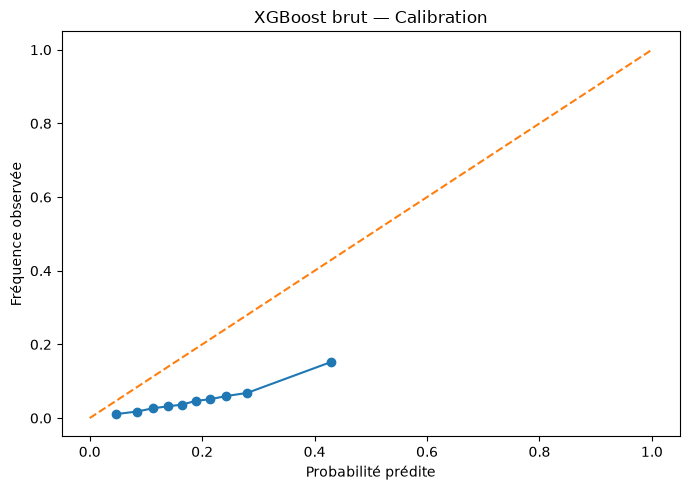

In [43]:
prob_true_raw, prob_pred_raw = (
    calibration_curve(
        y_calibration,
        xgb_raw_proba,
        n_bins=10,
        strategy="quantile"
    )
)

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    prob_pred_raw,
    prob_true_raw,
    marker="o"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "Probabilité prédite"
)

plt.ylabel(
    "Fréquence observée"
)

plt.title(
    "XGBoost brut — Calibration"
)

plt.tight_layout()

plt.show()

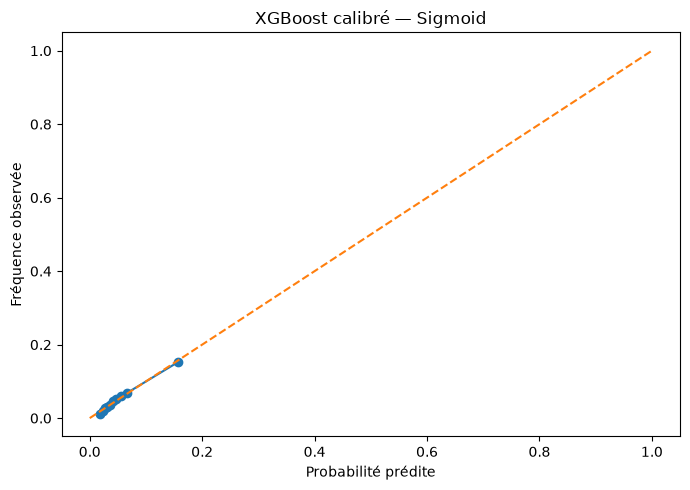

In [44]:
prob_true_sigmoid, prob_pred_sigmoid = (
    calibration_curve(
        y_calibration,
        xgb_sigmoid_proba,
        n_bins=10,
        strategy="quantile"
    )
)

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    prob_pred_sigmoid,
    prob_true_sigmoid,
    marker="o"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "Probabilité prédite"
)

plt.ylabel(
    "Fréquence observée"
)

plt.title(
    "XGBoost calibré — Sigmoid"
)

plt.tight_layout()

plt.show()

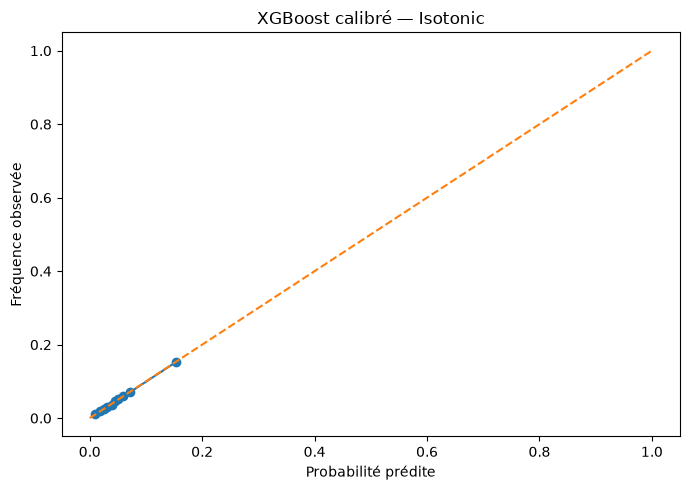

In [45]:
prob_true_isotonic, prob_pred_isotonic = (
    calibration_curve(
        y_calibration,
        xgb_isotonic_proba,
        n_bins=10,
        strategy="quantile"
    )
)

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    prob_pred_isotonic,
    prob_true_isotonic,
    marker="o"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "Probabilité prédite"
)

plt.ylabel(
    "Fréquence observée"
)

plt.title(
    "XGBoost calibré — Isotonic"
)

plt.tight_layout()

plt.show()

In [46]:
calibration_results

,model,pr_auc,roc_auc,brier,log_loss
0,logistic_tuned,0.090115,0.629518,0.047084,0.193654
1,xgb_raw,0.144078,0.700314,0.070053,0.274954
2,xgb_sigmoid,0.144051,0.700978,0.045647,0.184546
3,xgb_isotonic,0.144047,0.700993,0.045624,0.184468


In [47]:
calibrated_only = (
    calibration_results[
        calibration_results[
            "model"
        ].isin(
            [
                "xgb_sigmoid",
                "xgb_isotonic"
            ]
        )
    ]
    .sort_values(
        "brier"
    )
)

calibrated_only

,model,pr_auc,roc_auc,brier,log_loss
3,xgb_isotonic,0.144047,0.700993,0.045624,0.184468
2,xgb_sigmoid,0.144051,0.700978,0.045647,0.184546


In [48]:
selected_calibration_name = (
    calibrated_only
    .iloc[0]["model"]
)

print(
    "Calibration candidate :",
    selected_calibration_name
)

Calibration candidate : xgb_isotonic


In [49]:
if (
    selected_calibration_name
    == "xgb_sigmoid"
):

    selected_proba = (
        xgb_sigmoid_proba
    )

else:

    selected_proba = (
        xgb_isotonic_proba
    )

In [50]:
precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_calibration,
        selected_proba
    )
)

In [51]:
precision_for_thresholds = (
    precision_values[:-1]
)

recall_for_thresholds = (
    recall_values[:-1]
)

f1_values = (
    2
    *
    precision_for_thresholds
    *
    recall_for_thresholds
    /
    (
        precision_for_thresholds
        +
        recall_for_thresholds
        +
        1e-12
    )
)

In [52]:
threshold_table = pd.DataFrame({
    "threshold":
        thresholds,

    "precision":
        precision_for_thresholds,

    "recall":
        recall_for_thresholds,

    "f1":
        f1_values
})

In [54]:
best_f1_row = (
    threshold_table
    .iloc[
        threshold_table[
            "f1"
        ].idxmax()
    ]
)

best_f1_row

threshold    0.103271
precision    0.180027
recall       0.248484
f1           0.208787
Name: 16606, dtype: float64

In [55]:
technical_threshold = float(
    best_f1_row[
        "threshold"
    ]
)

print(
    "Seuil max F1 :",
    technical_threshold
)

print(
    "Precision :",
    best_f1_row["precision"]
)

print(
    "Recall :",
    best_f1_row["recall"]
)

print(
    "F1 :",
    best_f1_row["f1"]
)

Seuil max F1 : 0.10327080885569255
Precision : 0.18002663115845538
Recall : 0.2484837346076089
F1 : 0.20878696625694462


In [56]:
recall_70_candidates = (
    threshold_table[
        threshold_table[
            "recall"
        ] >= 0.70
    ]
    .copy()
)

In [57]:
if not recall_70_candidates.empty:

    best_precision_at_recall_70 = (
        recall_70_candidates
        .sort_values(
            "precision",
            ascending=False
        )
        .iloc[0]
    )

    print(
        best_precision_at_recall_70
    )

else:

    print(
        "Aucun seuil avec recall >= 70 %"
    )

threshold    0.045372
precision    0.080294
recall       0.700055
f1           0.144065
Name: 7580, dtype: float64


In [58]:
threshold_table.to_csv(
    REPORT_DIR
    / "threshold_analysis.csv",
    index=False
)

In [59]:
technical_predictions = (
    selected_proba
    >= technical_threshold
).astype(int)

In [60]:
cm = confusion_matrix(
    y_calibration,
    technical_predictions
)

cm

array([[96688,  6158],
       [ 4089,  1352]])

In [61]:
tn, fp, fn, tp = cm.ravel()

print(
    "True Negatives  :",
    tn
)

print(
    "False Positives :",
    fp
)

print(
    "False Negatives :",
    fn
)

print(
    "True Positives  :",
    tp
)

True Negatives  : 96688
False Positives : 6158
False Negatives : 4089
True Positives  : 1352


In [62]:
print(
    "Precision :",
    precision_score(
        y_calibration,
        technical_predictions,
        zero_division=0
    )
)

print(
    "Recall :",
    recall_score(
        y_calibration,
        technical_predictions,
        zero_division=0
    )
)

print(
    "F1 :",
    f1_score(
        y_calibration,
        technical_predictions,
        zero_division=0
    )
)

Precision : 0.18002663115845538
Recall : 0.2484837346076089
F1 : 0.20878696625743187


In [63]:
candidate_configuration = {

    "task":
        "claim_occurrence",

    "model":
        "xgboost",

    "best_cv_pr_auc":
        float(
            xgb_search.best_score_
        ),

    "best_parameters":
        xgb_search.best_params_,

    "calibration":
        selected_calibration_name,

    "technical_threshold":
        float(
            technical_threshold
        ),

    "threshold_policy":
        "maximum_f1_on_internal_calibration_set",

    "test_used":
        False
}

In [64]:
with open(
    METADATA_DIR
    / "claim_occurrence_candidate.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        candidate_configuration,
        f,
        indent=4,
        ensure_ascii=False
    )

In [65]:
summary = pd.DataFrame([
    {
        "model":
            "Logistic Tuned",

        "pr_auc":
            average_precision_score(
                y_calibration,
                logistic_calibration_proba
            ),

        "roc_auc":
            roc_auc_score(
                y_calibration,
                logistic_calibration_proba
            ),

        "brier":
            brier_score_loss(
                y_calibration,
                logistic_calibration_proba
            )
    },

    {
        "model":
            "XGBoost Raw",

        "pr_auc":
            average_precision_score(
                y_calibration,
                xgb_raw_proba
            ),

        "roc_auc":
            roc_auc_score(
                y_calibration,
                xgb_raw_proba
            ),

        "brier":
            brier_score_loss(
                y_calibration,
                xgb_raw_proba
            )
    },

    {
        "model":
            "XGBoost Sigmoid",

        "pr_auc":
            average_precision_score(
                y_calibration,
                xgb_sigmoid_proba
            ),

        "roc_auc":
            roc_auc_score(
                y_calibration,
                xgb_sigmoid_proba
            ),

        "brier":
            brier_score_loss(
                y_calibration,
                xgb_sigmoid_proba
            )
    },

    {
        "model":
            "XGBoost Isotonic",

        "pr_auc":
            average_precision_score(
                y_calibration,
                xgb_isotonic_proba
            ),

        "roc_auc":
            roc_auc_score(
                y_calibration,
                xgb_isotonic_proba
            ),

        "brier":
            brier_score_loss(
                y_calibration,
                xgb_isotonic_proba
            )
    }
])

In [66]:
summary.round(6)

,model,pr_auc,roc_auc,brier
0,Logistic Tuned,0.090115,0.629518,0.047084
1,XGBoost Raw,0.144078,0.700314,0.070053
2,XGBoost Sigmoid,0.144051,0.700978,0.045647
3,XGBoost Isotonic,0.144047,0.700993,0.045624


In [67]:
summary.to_csv(
    REPORT_DIR
    / "candidate_model_summary.csv",
    index=False
)

In [68]:
print(
    "=" * 80
)

print(
    "RÉSULTATS TUNING + CALIBRATION"
)

print(
    "=" * 80
)


print(
    "\n=== LOGISTIC TUNING ==="
)

print(
    "Best params :",
    logistic_search.best_params_
)

print(
    "Best CV PR-AUC :",
    logistic_search.best_score_
)


print(
    "\n=== XGBOOST TUNING ==="
)

print(
    "Best params :"
)

for key, value in (
    xgb_search
    .best_params_
    .items()
):

    print(
        key,
        "=",
        value
    )

print(
    "Best CV PR-AUC :",
    xgb_search.best_score_
)


print(
    "\n=== CALIBRATION COMPARISON ==="
)

print(
    calibration_results
    .round(6)
    .to_string(
        index=False
    )
)


print(
    "\n=== CALIBRATION SÉLECTIONNÉE ==="
)

print(
    selected_calibration_name
)


print(
    "\n=== SEUIL TECHNIQUE MAX F1 ==="
)

print(
    best_f1_row
)


print(
    "\n=== CONFUSION MATRIX ==="
)

print(
    cm
)


print(
    "\n=== METRICS AU SEUIL ==="
)

print(
    "Precision :",
    precision_score(
        y_calibration,
        technical_predictions,
        zero_division=0
    )
)

print(
    "Recall :",
    recall_score(
        y_calibration,
        technical_predictions,
        zero_division=0
    )
)

print(
    "F1 :",
    f1_score(
        y_calibration,
        technical_predictions,
        zero_division=0
    )
)


print(
    "\n=== SUMMARY ==="
)

print(
    summary
    .round(6)
    .to_string(
        index=False
    )
)


print(
    "\nTEST FINAL UTILISÉ ? NON"
)

print(
    "=" * 80
)

RÉSULTATS TUNING + CALIBRATION

=== LOGISTIC TUNING ===
Best params : {'model__C': 0.001}
Best CV PR-AUC : 0.09324613124601637

=== XGBOOST TUNING ===
Best params :
model__subsample = 0.9
model__scale_pos_weight = 5.0
model__reg_lambda = 5.0
model__reg_alpha = 0.01
model__n_estimators = 200
model__min_child_weight = 1
model__max_depth = 6
model__learning_rate = 0.05
model__colsample_bytree = 0.7
Best CV PR-AUC : 0.14359548747868847

=== CALIBRATION COMPARISON ===
         model   pr_auc  roc_auc    brier  log_loss
logistic_tuned 0.090115 0.629518 0.047084  0.193654
       xgb_raw 0.144078 0.700314 0.070053  0.274954
   xgb_sigmoid 0.144051 0.700978 0.045647  0.184546
  xgb_isotonic 0.144047 0.700993 0.045624  0.184468

=== CALIBRATION SÉLECTIONNÉE ===
xgb_isotonic

=== SEUIL TECHNIQUE MAX F1 ===
threshold    0.103271
precision    0.180027
recall       0.248484
f1           0.208787
Name: 16606, dtype: float64

=== CONFUSION MATRIX ===
[[96688  6158]
 [ 4089  1352]]

=== METRICS AU SEUI

# Analyse du tuning et de la calibration — Claim Occurrence

## 1. Tuning de Logistic Regression

La recherche d'hyperparamètres pour Logistic Regression a sélectionné :

`C = 0.001`

La meilleure PR-AUC obtenue en validation croisée est :

**PR-AUC CV = 0.09325**

Cette valeur reste proche des performances observées lors de l'étape
de comparaison initiale.

La régression logistique reste donc une baseline statistique utile,
simple et interprétable, mais son pouvoir de discrimination reste
nettement inférieur à celui de XGBoost.

Sur le jeu interne de calibration, Logistic Regression obtient :

- PR-AUC = **0.09012**
- ROC-AUC = **0.62952**
- Brier Score = **0.04708**
- Log Loss = **0.19365**

Le modèle conserve une qualité probabiliste correcte,
mais sa capacité à distinguer les contrats sinistrés des contrats
sans sinistre reste limitée.

---

## 2. Tuning de XGBoost

La meilleure configuration identifiée est :

- `n_estimators = 200`
- `learning_rate = 0.05`
- `max_depth = 6`
- `min_child_weight = 1`
- `subsample = 0.9`
- `colsample_bytree = 0.7`
- `reg_alpha = 0.01`
- `reg_lambda = 5.0`
- `scale_pos_weight = 5.0`

La meilleure PR-AUC obtenue durant le tuning est :

**PR-AUC CV = 0.14360**

La recherche sélectionne notamment un `scale_pos_weight = 5`,
plus faible que le ratio brut entre classes utilisé lors de la première
expérience.

Cette configuration conserve donc une pondération de la classe minoritaire,
mais de manière moins agressive.

Les résultats de cette recherche ne doivent pas être comparés
strictement chiffre par chiffre avec la validation croisée précédente,
car le tuning a été réalisé sur une sous-partie du jeu de développement
et avec un protocole de Cross-Validation différent.

Ils confirment néanmoins que XGBoost reste le modèle présentant
la meilleure capacité de discrimination.

---

# 3. XGBoost avant calibration

Sur le jeu interne de calibration, XGBoost brut obtient :

- PR-AUC = **0.14408**
- ROC-AUC = **0.70031**
- Brier Score = **0.07005**
- Log Loss = **0.27495**

La discrimination est nettement supérieure à celle de Logistic Regression.

Cependant, le Brier Score reste relativement élevé.

Cela signifie que le modèle classe correctement les observations
selon leur niveau de risque relatif, mais que ses probabilités brutes
ne sont pas encore suffisamment fiables pour être interprétées directement
comme des probabilités de sinistre.

Autrement dit :

un score XGBoost élevé permet de distinguer un contrat plus risqué
d'un contrat moins risqué, mais une sortie brute de `0.20`
ne doit pas encore être interprétée automatiquement comme
« 20 % de probabilité réelle de sinistre ».

---

# 4. Calibration Sigmoid

Après calibration par méthode sigmoid, les résultats deviennent :

- PR-AUC = **0.14405**
- ROC-AUC = **0.70098**
- Brier Score = **0.04565**
- Log Loss = **0.18455**

La PR-AUC reste pratiquement identique à celle du modèle brut.

Cela indique que la calibration ne détruit pas la capacité
de classement de XGBoost.

En revanche, le Brier Score diminue fortement :

`0.07005 → 0.04565`

La qualité probabiliste est donc considérablement améliorée.

---

# 5. Calibration Isotonic

La calibration isotonic obtient :

- PR-AUC = **0.14405**
- ROC-AUC = **0.70099**
- Brier Score = **0.04562**
- Log Loss = **0.18447**

Cette méthode obtient la meilleure valeur de Brier Score
parmi les configurations testées.

La différence avec sigmoid est toutefois extrêmement faible :

- Brier sigmoid = **0.045647**
- Brier isotonic = **0.045624**

La différence absolue n'est que d'environ :

**0.000023**

Les deux méthodes donnent donc des résultats pratiquement équivalents
sur ce jeu de validation.

Selon la règle de sélection définie dans l'expérience,
qui choisit la calibration présentant le Brier Score le plus faible,
la méthode retenue est :

## `XGBoost + Isotonic Calibration`

Cette sélection est réalisée avant toute consultation du jeu de test final.

Il ne faut cependant pas conclure que isotonic est universellement
supérieur à sigmoid : l'écart observé est très faible.

---

# 6. Comparaison avec Logistic Regression

Les résultats sur le jeu interne de calibration sont :

| Modèle | PR-AUC | ROC-AUC | Brier |
|---|---:|---:|---:|
| Logistic Regression Tuned | 0.09012 | 0.62952 | 0.04708 |
| XGBoost Raw | 0.14408 | 0.70031 | 0.07005 |
| XGBoost + Sigmoid | 0.14405 | 0.70098 | 0.04565 |
| XGBoost + Isotonic | **0.14405** | **0.70099** | **0.04562** |

Avant calibration, Logistic Regression produisait des probabilités
plus fiables que XGBoost.

Après calibration, cette situation change.

XGBoost calibré conserve une discrimination nettement supérieure
à Logistic Regression tout en obtenant également un meilleur
Brier Score :

`0.04562 < 0.04708`

Le modèle XGBoost calibré devient donc le candidat principal
pour la prédiction probabiliste de l'occurrence d'un sinistre.

---

# 7. Effet de la calibration

La calibration apporte ici un résultat important :

### Avant calibration

XGBoost possède une bonne capacité de classement,
mais des probabilités insuffisamment calibrées.

### Après calibration

La PR-AUC reste presque inchangée :

`0.14408 → 0.14405`

alors que le Brier Score s'améliore fortement :

`0.07005 → 0.04562`

La calibration améliore donc principalement la qualité
des probabilités sans sacrifier la capacité de discrimination.

Cela est particulièrement important pour l'application finale,
car une probabilité affichée à l'utilisateur doit avoir
une interprétation statistique raisonnable.

---

# 8. Analyse du seuil de classification

La calibration fournit une probabilité continue.

Pour transformer cette probabilité en classe binaire,
un seuil de décision est nécessaire.

Le seuil de `0.5` n'est pas automatiquement approprié
dans un problème où seulement environ 5 % des observations
appartiennent à la classe positive.

Une recherche du seuil maximisant le F1-score sur le jeu
interne de calibration donne :

**Seuil = 0.10327**

À ce seuil :

- Precision = **0.18003**
- Recall = **0.24848**
- F1-score = **0.20879**

Ce seuil améliore le compromis entre Precision et Recall
sur ce jeu de validation.

---

# 9. Matrice de confusion au seuil technique

La matrice obtenue est :

| | Prédit 0 | Prédit 1 |
|---|---:|---:|
| Réel 0 | 96 688 | 6 158 |
| Réel 1 | 4 089 | 1 352 |

Cela signifie que :

- **1 352** contrats avec sinistre sont correctement détectés ;
- **4 089** contrats avec sinistre ne sont pas détectés ;
- **6 158** contrats sans sinistre sont signalés comme positifs ;
- **96 688** contrats sans sinistre sont correctement classés.

La Precision de **18 %** signifie qu'environ 18 % des contrats
signalés positifs correspondent réellement à un contrat sinistré.

Le Recall de **24,85 %** signifie qu'environ un quart des contrats
sinistrés sont détectés avec ce seuil.

---

# 10. Interprétation du seuil

Le seuil `0.10327` ne doit pas être présenté comme
« le seuil optimal pour l'assureur ».

Il s'agit uniquement d'un :

## seuil technique de prototype

choisi pour maximiser le F1-score sur la validation interne.

Le seuil métier réel dépendrait notamment du coût :

- d'un faux positif ;
- d'un faux négatif ;
- d'une investigation supplémentaire ;
- d'une mauvaise classification du risque.

Ces coûts ne sont pas disponibles dans le dataset.

Le seuil ne peut donc pas être optimisé économiquement à ce stade.

---

# 11. Pourquoi le Recall est inférieur à celui du premier XGBoost ?

Lors de l'expérience précédente, XGBoost avec une pondération
plus forte de la classe positive produisait environ :

**Recall ≈ 0.616**

au seuil brut de `0.5`.

Après tuning et calibration, nous analysons maintenant
un autre modèle, avec :

- `scale_pos_weight = 5` ;
- une calibration des probabilités ;
- un seuil différent ;
- un objectif de maximisation du F1-score.

Les deux résultats ne représentent donc pas exactement
la même règle de décision.

Un Recall plus faible ici n'indique pas nécessairement
une dégradation de la capacité de classement du modèle.

La PR-AUC reste autour de **0.144**, ce qui confirme
que le pouvoir de discrimination est conservé.

Le changement concerne principalement le compromis
entre Precision et Recall au seuil choisi.

---

# 12. Configuration candidate verrouillée

Avant ouverture du jeu de test final, la configuration candidate est :

## Modèle

XGBoost

## Hyperparamètres

`n_estimators = 200`

`learning_rate = 0.05`

`max_depth = 6`

`min_child_weight = 1`

`subsample = 0.9`

`colsample_bytree = 0.7`

`reg_alpha = 0.01`

`reg_lambda = 5.0`

`scale_pos_weight = 5.0`

## Calibration

Isotonic

## Seuil technique

`0.103271`

## Règle de sélection du seuil

Maximum du F1-score sur le jeu interne de calibration.

## Métrique principale

PR-AUC.

## Jeu de test final

Toujours non utilisé.

---

# 13. Conclusion

Les résultats confirment XGBoost comme modèle principal
pour la prédiction de l'occurrence d'un sinistre.

Le tuning conserve une PR-AUC d'environ **0.144**.

Le principal problème du modèle initial concernait la calibration
des probabilités.

L'application d'une calibration isotonic réduit le Brier Score :

**0.07005 → 0.04562**

tout en conservant pratiquement toute la discrimination :

**PR-AUC ≈ 0.144**

Le modèle calibré obtient également un meilleur Brier Score
que la Logistic Regression optimisée.

La configuration du modèle peut donc maintenant être verrouillée
avant l'évaluation finale.

Le seuil de `0.10327` est conservé uniquement comme seuil technique
issu de la validation et ne constitue pas un seuil métier définitif.

Le jeu de test final n'a encore participé à aucune décision
de modélisation.

## Étape suivante

`08_claim_occurrence_final_evaluation.ipynb`

La prochaine étape consistera à :

réentraîner la configuration verrouillée sur les données
de développement selon une procédure compatible avec la calibration,

puis ouvrir pour la première fois le jeu de test final afin de mesurer :

PR-AUC,
ROC-AUC,
Brier Score,
Log Loss,
Precision,
Recall,
F1,
matrice de confusion
et courbe de calibration.

Aucune modification des hyperparamètres, de la calibration
ou du seuil ne devra être effectuée après consultation
des résultats du test final.